In [1]:
# If needed, run this cell once
# !pip install pandas numpy matplotlib seaborn scikit-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import zipfile
import os
import warnings

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")

print("All libraries imported successfully!")

All libraries imported successfully!


In [6]:
zip_path = r"C:\Users\navya\Downloads\archive (2).zip"


if not os.path.exists(zip_path):
    raise FileNotFoundError(
        f"ZIP file not found.\nPlease check this path:\n{zip_path}"
    )

with zipfile.ZipFile(zip_path, "r") as z:
    files = z.namelist()
    
    print("Files inside ZIP:")
    for file in files:
        print(file)
    
    csv_files = [
        file for file in files
        if file.lower().endswith(".csv")
    ]
    
    if len(csv_files) == 0:
        raise FileNotFoundError("No CSV file found inside the ZIP file.")
    
    csv_file = csv_files[0]
    
    print("\n CSV selected:", csv_file)
    
    with z.open(csv_file) as f:
        df = pd.read_csv(f)

print("\nDataset loaded successfully!")
print("Shape:", df.shape)

Files inside ZIP:
flight_delays.csv

 CSV selected: flight_delays.csv

Dataset loaded successfully!
Shape: (1747627, 16)


In [7]:
print("First 5 rows:")
display(df.head())

print("\nColumn names:")
print(df.columns.tolist())

First 5 rows:


,FlightID,Airline,FlightNumber,Origin,Destination,ScheduledDeparture,ActualDeparture,ScheduledArrival,ActualArrival,DelayMinutes,DelayReason,Cancelled,Diverted,AircraftType,TailNumber,Distance
0,1,United,4558,ORD,MIA,2024-09-01 08:11,2024-09-01 08:30,2024-09-01 12:11,2024-09-01 12:19,8,Weather,True,False,Boeing 737,N71066,1031
1,2,Delta,8021,LAX,MIA,2024-09-01 10:25,2024-09-01 10:41,2024-09-01 13:25,2024-09-01 13:27,2,Air Traffic Control,True,True,Airbus A320,N22657,1006
2,3,Southwest,7520,DFW,SFO,2024-09-01 16:53,2024-09-01 17:05,2024-09-01 17:53,2024-09-01 18:07,14,Weather,True,True,Boeing 737,N95611,2980
3,4,Delta,2046,ORD,BOS,2024-09-01 14:44,2024-09-01 15:04,2024-09-01 18:44,2024-09-01 18:34,-10,NaN,False,False,Boeing 777,N90029,1408
4,5,Delta,6049,LAX,SEA,2024-09-01 01:51,2024-09-01 02:08,2024-09-01 05:51,2024-09-01 06:15,24,Air Traffic Control,False,True,Boeing 737,N27417,2298



Column names:
['FlightID', 'Airline', 'FlightNumber', 'Origin', 'Destination', 'ScheduledDeparture', 'ActualDeparture', 'ScheduledArrival', 'ActualArrival', 'DelayMinutes', 'DelayReason', 'Cancelled', 'Diverted', 'AircraftType', 'TailNumber', 'Distance']


In [8]:
print("Dataset Information")
print("=" * 50)

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nData Types:")
print(df.dtypes)

print("\nDataset Info:")
df.info()

Dataset Information
Rows: 1747627
Columns: 16

Data Types:
FlightID               int64
Airline               object
FlightNumber           int64
Origin                object
Destination           object
ScheduledDeparture    object
ActualDeparture       object
ScheduledArrival      object
ActualArrival         object
DelayMinutes           int64
DelayReason           object
Cancelled               bool
Diverted                bool
AircraftType          object
TailNumber            object
Distance               int64
dtype: object

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1747627 entries, 0 to 1747626
Data columns (total 16 columns):
 #   Column              Dtype 
---  ------              ----- 
 0   FlightID            int64 
 1   Airline             object
 2   FlightNumber        int64 
 3   Origin              object
 4   Destination         object
 5   ScheduledDeparture  object
 6   ActualDeparture     object
 7   ScheduledArrival    object
 8   ActualArri

In [9]:
missing = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Missing Percentage": (df.isnull().sum() / len(df)) * 100
})

missing = missing.sort_values(
    by="Missing Values",
    ascending=False
)

display(missing)

,Missing Values,Missing Percentage
DelayReason,468873,26.829123
FlightID,0,0.000000
Airline,0,0.000000
FlightNumber,0,0.000000
Origin,0,0.000000
Destination,0,0.000000
ScheduledDeparture,0,0.000000
ActualDeparture,0,0.000000
ScheduledArrival,0,0.000000
ActualArrival,0,0.000000


In [10]:
print("Duplicate rows before cleaning:", df.duplicated().sum())

df = df.drop_duplicates()

print("Duplicate rows after cleaning:", df.duplicated().sum())
print("New dataset shape:", df.shape)

Duplicate rows before cleaning: 0
Duplicate rows after cleaning: 0
New dataset shape: (1747627, 16)


In [12]:
# Create binary target variable

df["Delay"] = (df["DelayMinutes"] > 0).astype(int)

target_col = "Delay"

print("Target column created successfully!")
print("\nTarget values:")
print(df["Delay"].value_counts())

print("\nTarget meaning:")
print("0 = On-Time")
print("1 = Delayed")

Target column created successfully!

Target values:
Delay
1    1278754
0     468873
Name: count, dtype: int64

Target meaning:
0 = On-Time
1 = Delayed


In [13]:
print("Target column:", target_col)

print("\nTarget values:")
print(df[target_col].value_counts())

print("\nTarget percentages:")
print(
    df[target_col].value_counts(normalize=True) * 100
)

Target column: Delay

Target values:
Delay
1    1278754
0     468873
Name: count, dtype: int64

Target percentages:
Delay
1    73.170877
0    26.829123
Name: proportion, dtype: float64


In [14]:
print("Original target values:")
print(df[target_col].unique())

# If target is already numeric 0/1
if pd.api.types.is_numeric_dtype(df[target_col]):
    
    unique_values = sorted(df[target_col].dropna().unique())
    
    if set(unique_values).issubset({0, 1}):
        df[target_col] = df[target_col].astype(int)
    else:
        # Convert numeric values into binary
        df[target_col] = (
            df[target_col] > 0
        ).astype(int)

else:
    # Convert text target into binary
    target_text = df[target_col].astype(str).str.strip().str.lower()
    
    delayed_words = [
        "yes",
        "delayed",
        "delay",
        "true",
        "1"
    ]
    
    df[target_col] = target_text.apply(
        lambda x: 1 if x in delayed_words else 0
    )

print("\nConverted target values:")
print(df[target_col].value_counts())

Original target values:
[1 0]

Converted target values:
Delay
1    1278754
0     468873
Name: count, dtype: int64


In [15]:
# Numerical columns
numeric_columns = df.select_dtypes(
    include=["int64", "float64"]
).columns

for col in numeric_columns:
    if col != target_col:
        df[col] = df[col].fillna(
            df[col].median()
        )

# Categorical columns
categorical_columns = df.select_dtypes(
    include=["object"]
).columns

for col in categorical_columns:
    if df[col].isnull().sum() > 0:
        mode_value = df[col].mode()
        
        if len(mode_value) > 0:
            df[col] = df[col].fillna(
                mode_value[0]
            )
        else:
            df[col] = df[col].fillna("Unknown")

print("Missing values handled successfully.")

print("\nRemaining missing values:")
print(df.isnull().sum().sum())

Missing values handled successfully.

Remaining missing values:
0


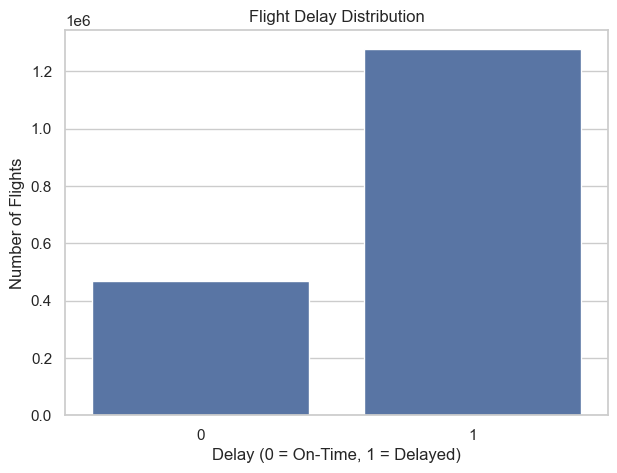

In [16]:
plt.figure(figsize=(7, 5))

sns.countplot(
    x=df[target_col]
)

plt.title("Flight Delay Distribution")
plt.xlabel("Delay (0 = On-Time, 1 = Delayed)")
plt.ylabel("Number of Flights")

plt.show()

In [17]:
delay_count = df[target_col].value_counts()

on_time = delay_count.get(0, 0)
delayed = delay_count.get(1, 0)

total = len(df)

print("Total flights:", total)
print("On-time flights:", on_time)
print("Delayed flights:", delayed)

print(
    "\nDelay percentage:",
    round((delayed / total) * 100, 2),
    "%"
)

print(
    "On-time percentage:",
    round((on_time / total) * 100, 2),
    "%"
)

Total flights: 1747627
On-time flights: 468873
Delayed flights: 1278754

Delay percentage: 73.17 %
On-time percentage: 26.83 %


In [18]:
possible_airline_columns = [
    "Airline",
    "airline",
    "Carrier",
    "carrier",
    "AIRLINE"
]

airline_col = None

for col in possible_airline_columns:
    if col in df.columns:
        airline_col = col
        break

print("Airline column:", airline_col)

Airline column: Airline


Delay rate by airline:


,Delay Rate (%)
Airline,
United,73.204205
Delta,73.201887
Southwest,73.175836
American Airlines,73.101683


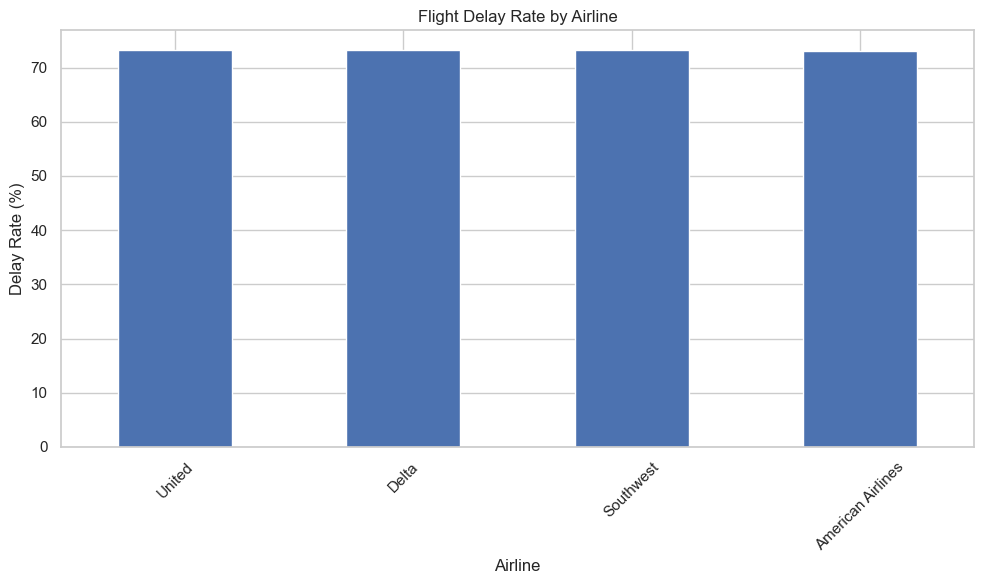

In [19]:
if airline_col is not None:

    airline_delay = (
        df.groupby(airline_col)[target_col]
        .mean()
        .sort_values(ascending=False)
        * 100
    )

    print("Delay rate by airline:")
    display(airline_delay.to_frame("Delay Rate (%)"))

    plt.figure(figsize=(10, 6))

    airline_delay.plot(kind="bar")

    plt.title("Flight Delay Rate by Airline")
    plt.xlabel("Airline")
    plt.ylabel("Delay Rate (%)")
    plt.xticks(rotation=45)
    plt.tight_layout()

    plt.show()

else:
    print("Airline column not available in this dataset.")

In [20]:
possible_departure = [
    "AirportFrom",
    "DepartureAirport",
    "DepAirport",
    "Origin",
    "OriginAirport",
    "From"
]

departure_col = None

for col in possible_departure:
    if col in df.columns:
        departure_col = col
        break

print("Departure airport column:", departure_col)

Departure airport column: Origin


Top 10 airports with highest delay rates:


,Delay Rate (%)
Origin,
JFK,73.237154
ATL,73.209880
ORD,73.162524
LAX,73.131293
DFW,73.113497


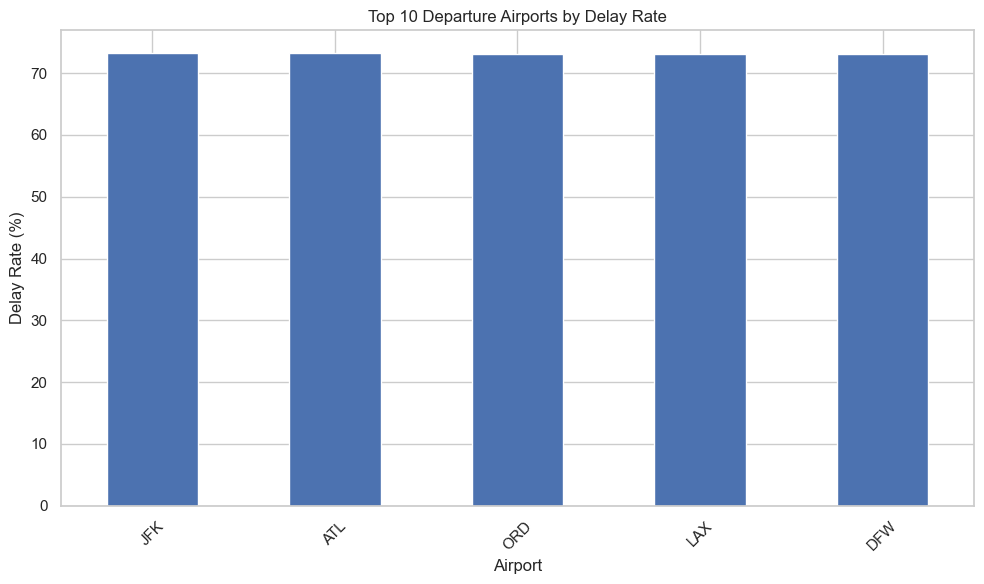

In [21]:
if departure_col is not None:

    airport_delay = (
        df.groupby(departure_col)[target_col]
        .mean()
        .sort_values(ascending=False)
        * 100
    )

    print("Top 10 airports with highest delay rates:")

    display(
        airport_delay.head(10).to_frame(
            "Delay Rate (%)"
        )
    )

    plt.figure(figsize=(10, 6))

    airport_delay.head(10).plot(
        kind="bar"
    )

    plt.title(
        "Top 10 Departure Airports by Delay Rate"
    )

    plt.xlabel("Airport")
    plt.ylabel("Delay Rate (%)")

    plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()

else:
    print("Departure airport column not available.")

In [75]:
total_flights = len(df)

on_time_flights = (df["Delay"] == 0).sum()
delayed_flights = (df["Delay"] == 1).sum()

on_time_percentage = (
    on_time_flights / total_flights
) * 100

delayed_percentage = (
    delayed_flights / total_flights
) * 100

print("Total Flights       :", total_flights)
print("On-Time Flights     :", on_time_flights)
print("Delayed Flights     :", delayed_flights)

print(
    "\nOn-Time Percentage  :",
    round(on_time_percentage, 2),
    "%"
)

print(
    "Delayed Percentage  :",
    round(delayed_percentage, 2),
    "%"
)

Total Flights       : 1747627
On-Time Flights     : 468873
Delayed Flights     : 1278754

On-Time Percentage  : 26.83 %
Delayed Percentage  : 73.17 %


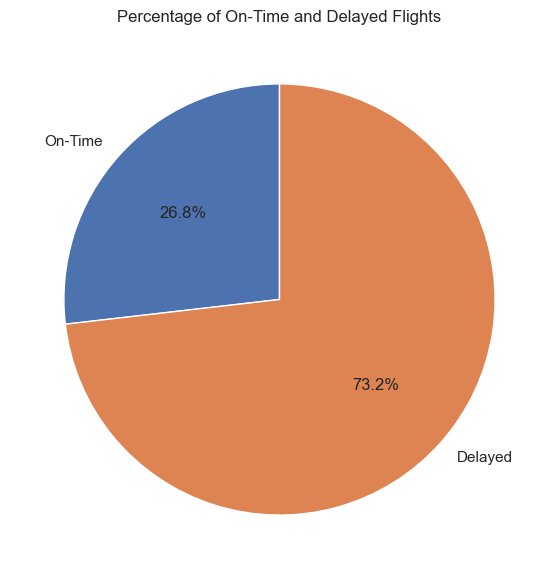

In [28]:
# ============================================================
# CELL 12: ON-TIME VS DELAYED FLIGHTS
# ============================================================

labels = ["On-Time", "Delayed"]
values = [on_time_flights, delayed_flights]

plt.figure(figsize=(7, 7))

plt.pie(
    values,
    labels=labels,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Percentage of On-Time and Delayed Flights")

plt.show()

In [76]:
# Numerical columns
numeric_columns = df.select_dtypes(
    include=["int64", "float64"]
).columns

for col in numeric_columns:

    if col != "Delay":

        df[col] = df[col].fillna(
            df[col].median()
        )

# Categorical columns
categorical_columns = df.select_dtypes(
    include=["object"]
).columns

for col in categorical_columns:

    if df[col].isnull().sum() > 0:

        mode_value = df[col].mode()

        if len(mode_value) > 0:

            df[col] = df[col].fillna(
                mode_value[0]
            )

print("Missing values handled successfully!")

print(
    "\nTotal remaining missing values:",
    df.isnull().sum().sum()
)

Missing values handled successfully!

Total remaining missing values: 0


In [77]:
# ============================================================
# CELL 14: CONVERT DATE/TIME COLUMNS
# ============================================================

datetime_columns = [
    "ScheduledDeparture",
    "ActualDeparture",
    "ScheduledArrival",
    "ActualArrival"
]

for col in datetime_columns:

    if col in df.columns:

        df[col] = pd.to_datetime(
            df[col],
            errors="coerce"
        )

print("Date/time conversion completed!")

print(df[
    [
        "ScheduledDeparture",
        "ActualDeparture",
        "ScheduledArrival",
        "ActualArrival"
    ]
].head())

Date/time conversion completed!
   ScheduledDeparture     ActualDeparture    ScheduledArrival  \
0 2024-09-01 08:11:00 2024-09-01 08:30:00 2024-09-01 12:11:00   
1 2024-09-01 10:25:00 2024-09-01 10:41:00 2024-09-01 13:25:00   
2 2024-09-01 16:53:00 2024-09-01 17:05:00 2024-09-01 17:53:00   
3 2024-09-01 14:44:00 2024-09-01 15:04:00 2024-09-01 18:44:00   
4 2024-09-01 01:51:00 2024-09-01 02:08:00 2024-09-01 05:51:00   

        ActualArrival  
0 2024-09-01 12:19:00  
1 2024-09-01 13:27:00  
2 2024-09-01 18:07:00  
3 2024-09-01 18:34:00  
4 2024-09-01 06:15:00  


In [79]:
# ============================================================
 CREATE TIME FEATURES
# ============================================================

df["DepartureHour"] = (
    df["ScheduledDeparture"].dt.hour
)

df["DepartureDay"] = (
    df["ScheduledDeparture"].dt.day
)

df["DepartureMonth"] = (
    df["ScheduledDeparture"].dt.month
)

df["DepartureDayOfWeek"] = (
    df["ScheduledDeparture"].dt.dayofweek
)

print("Time-based features created!")

display(
    df[
        [
            "ScheduledDeparture",
            "DepartureHour",
            "DepartureDay",
            "DepartureMonth",
            "DepartureDayOfWeek"
        ]
    ].head()
)

IndentationError: unexpected indent (383849555.py, line 2)

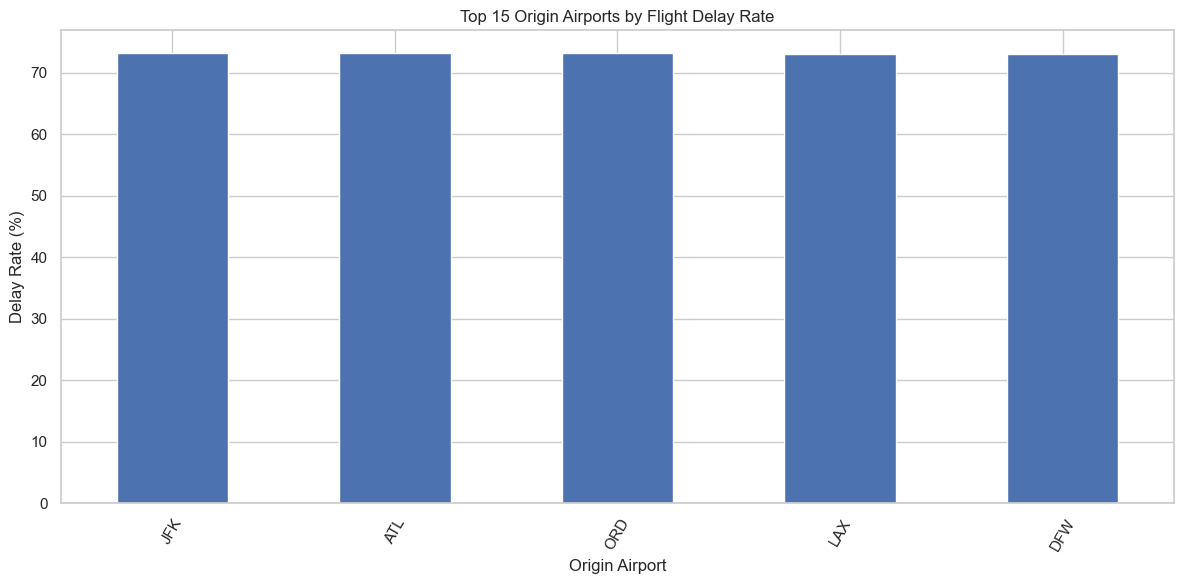

In [35]:
# ============================================================
# CELL 19: ORIGIN AIRPORT VISUALIZATION
# ============================================================

plt.figure(figsize=(12, 6))

origin_delay.head(15).plot(
    kind="bar"
)

plt.title(
    "Top 15 Origin Airports by Flight Delay Rate"
)

plt.xlabel("Origin Airport")
plt.ylabel("Delay Rate (%)")

plt.xticks(rotation=60)

plt.tight_layout()
plt.show()

In [36]:
# ============================================================
# CELL 20: DESTINATION AIRPORT DELAY ANALYSIS
# ============================================================

destination_delay = (
    df.groupby("Destination")["Delay"]
    .mean()
    .sort_values(ascending=False)
    * 100
)

print("Top 15 Destination Airports by Delay Rate:")

display(
    destination_delay.head(15).to_frame(
        "Delay Rate (%)"
    )
)

Top 15 Destination Airports by Delay Rate:


,Delay Rate (%)
Destination,
SFO,73.221048
MIA,73.202204
SEA,73.187146
JFK,73.148328
BOS,73.095677


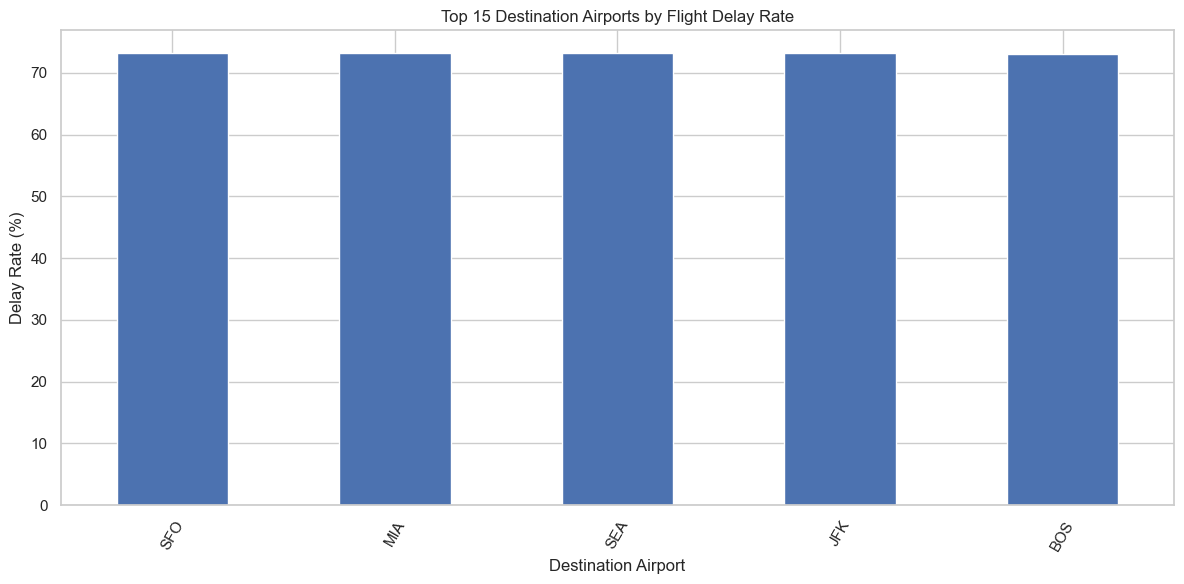

In [37]:
# ============================================================
# CELL 21: DESTINATION AIRPORT VISUALIZATION
# ============================================================

plt.figure(figsize=(12, 6))

destination_delay.head(15).plot(
    kind="bar"
)

plt.title(
    "Top 15 Destination Airports by Flight Delay Rate"
)

plt.xlabel("Destination Airport")
plt.ylabel("Delay Rate (%)")

plt.xticks(rotation=60)

plt.tight_layout()
plt.show()

In [38]:
# ============================================================
# CELL 22: DELAY BY DEPARTURE HOUR
# ============================================================

hour_delay = (
    df.groupby("DepartureHour")["Delay"]
    .mean()
    * 100
)

print("Delay Rate by Departure Hour:")

display(
    hour_delay.to_frame(
        "Delay Rate (%)"
    )
)

Delay Rate by Departure Hour:


,Delay Rate (%)
DepartureHour,
0,72.938631
1,73.433495
2,73.107652
3,73.157742
4,73.574753
5,73.144201
6,72.968516
7,73.232740
8,73.144813


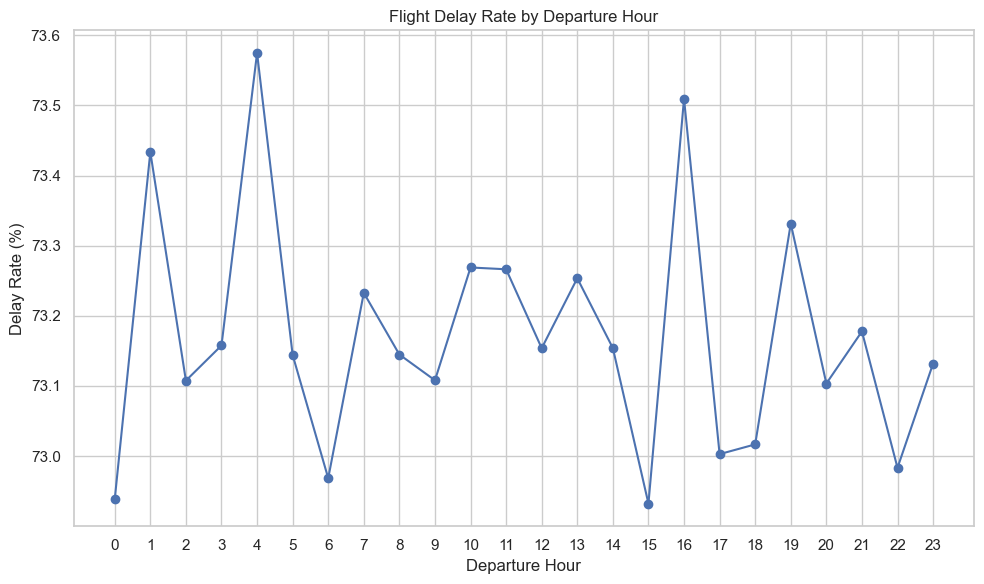

In [39]:
# ============================================================
# CELL 23: DELAY BY TIME PERIOD
# ============================================================

plt.figure(figsize=(10, 6))

hour_delay.plot(
    kind="line",
    marker="o"
)

plt.title(
    "Flight Delay Rate by Departure Hour"
)

plt.xlabel("Departure Hour")
plt.ylabel("Delay Rate (%)")

plt.xticks(range(0, 24))

plt.grid(True)

plt.tight_layout()
plt.show()

In [40]:
# ============================================================
# CELL 24: DELAY BY DAY OF WEEK
# ============================================================

day_delay = (
    df.groupby("DepartureDayOfWeek")["Delay"]
    .mean()
    * 100
)

day_names = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

day_delay.index = [
    day_names[i]
    for i in day_delay.index
]

display(
    day_delay.to_frame(
        "Delay Rate (%)"
    )
)

,Delay Rate (%)
Sunday,73.170877


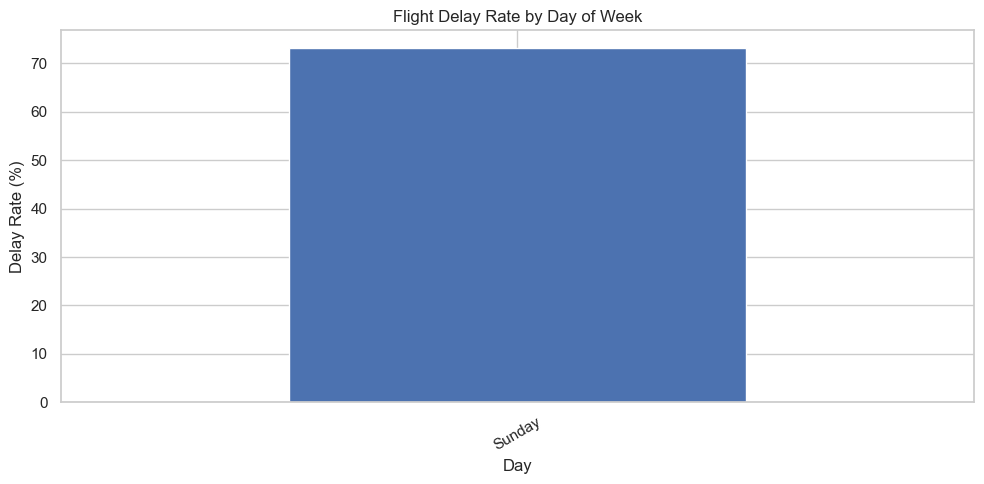

In [41]:
# ============================================================
# CELL 25: DAY OF WEEK VISUALIZATION
# ============================================================

plt.figure(figsize=(10, 5))

day_delay.plot(
    kind="bar"
)

plt.title(
    "Flight Delay Rate by Day of Week"
)

plt.xlabel("Day")
plt.ylabel("Delay Rate (%)")

plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

In [42]:
# ============================================================
# CELL 26: CREATE ROUTE
# ============================================================

df["Route"] = (
    df["Origin"].astype(str)
    + " -> "
    + df["Destination"].astype(str)
)

route_delay = (
    df.groupby("Route")["Delay"]
    .mean()
    .sort_values(ascending=False)
    * 100
)

print("Top 15 Routes with Highest Delay Rate:")

display(
    route_delay.head(15).to_frame(
        "Delay Rate (%)"
    )
)

Top 15 Routes with Highest Delay Rate:


,Delay Rate (%)
Route,
JFK -> MIA,73.666301
ATL -> SEA,73.547040
ORD -> JFK,73.384847
LAX -> SFO,73.345162
LAX -> BOS,73.340578
JFK -> SFO,73.325963
ATL -> SFO,73.286120
ORD -> SEA,73.276826
ATL -> JFK,73.273037


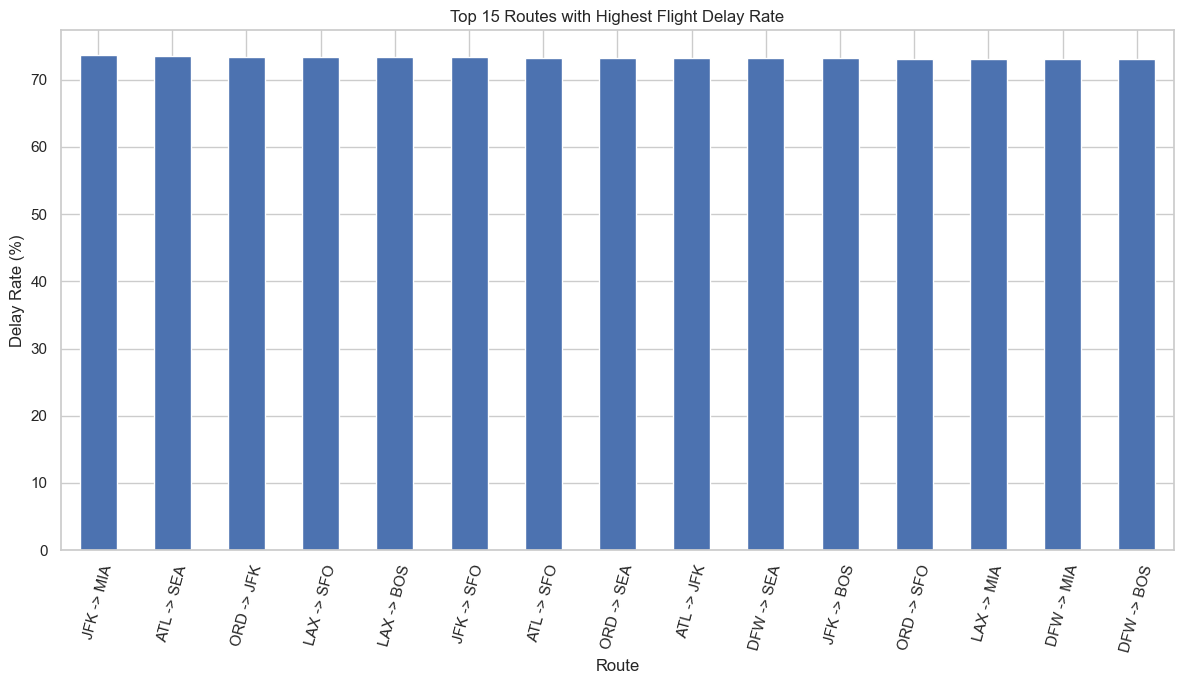

In [43]:
# ============================================================
# CELL 27: ROUTE DELAY VISUALIZATION
# ============================================================

plt.figure(figsize=(12, 7))

route_delay.head(15).plot(
    kind="bar"
)

plt.title(
    "Top 15 Routes with Highest Flight Delay Rate"
)

plt.xlabel("Route")
plt.ylabel("Delay Rate (%)")

plt.xticks(rotation=75)

plt.tight_layout()
plt.show()

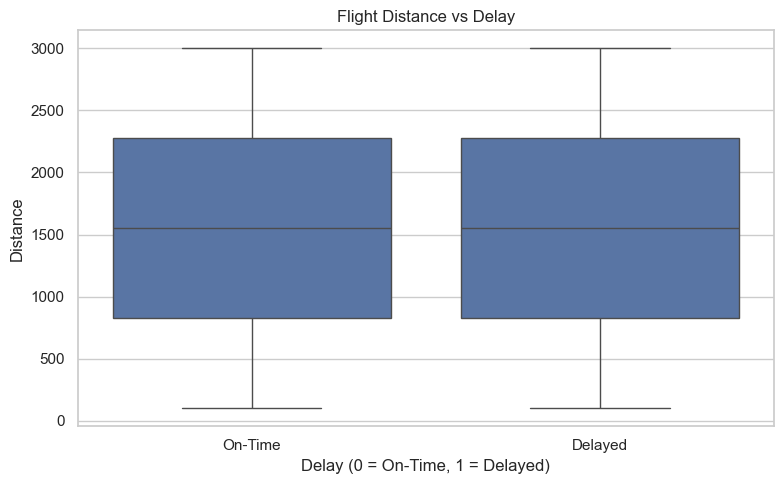

In [44]:
# ============================================================
# CELL 28: DISTANCE VS DELAY
# ============================================================

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Delay",
    y="Distance"
)

plt.title(
    "Flight Distance vs Delay"
)

plt.xlabel(
    "Delay (0 = On-Time, 1 = Delayed)"
)

plt.ylabel("Distance")

plt.xticks(
    [0, 1],
    ["On-Time", "Delayed"]
)

plt.tight_layout()
plt.show()

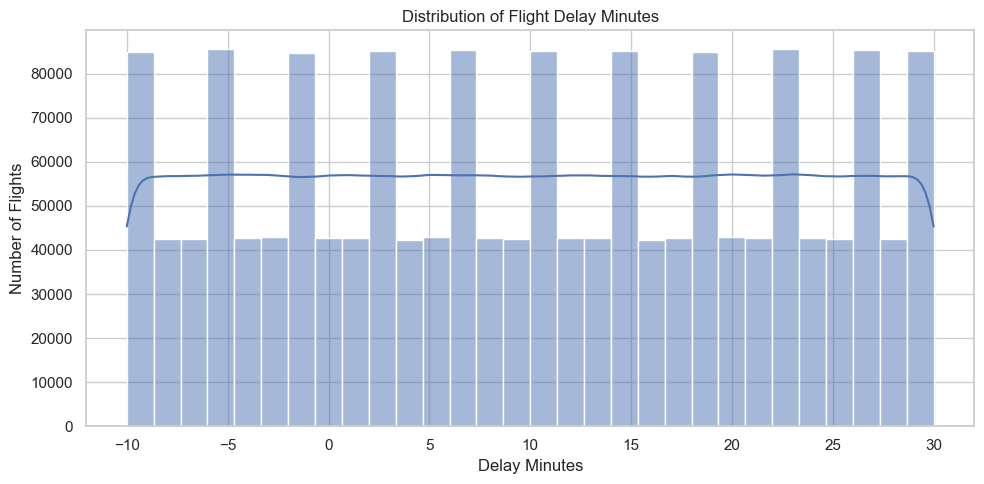

In [45]:
# ============================================================
# CELL 29: DELAY MINUTES DISTRIBUTION
# ============================================================

plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x="DelayMinutes",
    bins=30,
    kde=True
)

plt.title("Distribution of Flight Delay Minutes")

plt.xlabel("Delay Minutes")
plt.ylabel("Number of Flights")

plt.tight_layout()
plt.show()

In [46]:
# ============================================================
# CELL 30: DELAY REASON ANALYSIS
# ============================================================

if "DelayReason" in df.columns:

    reason_delay = (
        df[df["Delay"] == 1]["DelayReason"]
        .value_counts()
    )

    print("Delay Reasons:")
    display(reason_delay.to_frame("Number of Delays"))

else:

    print("DelayReason column not available.")

Delay Reasons:


,Number of Delays
DelayReason,
Air Traffic Control,426488
Maintenance,426168
Weather,426098


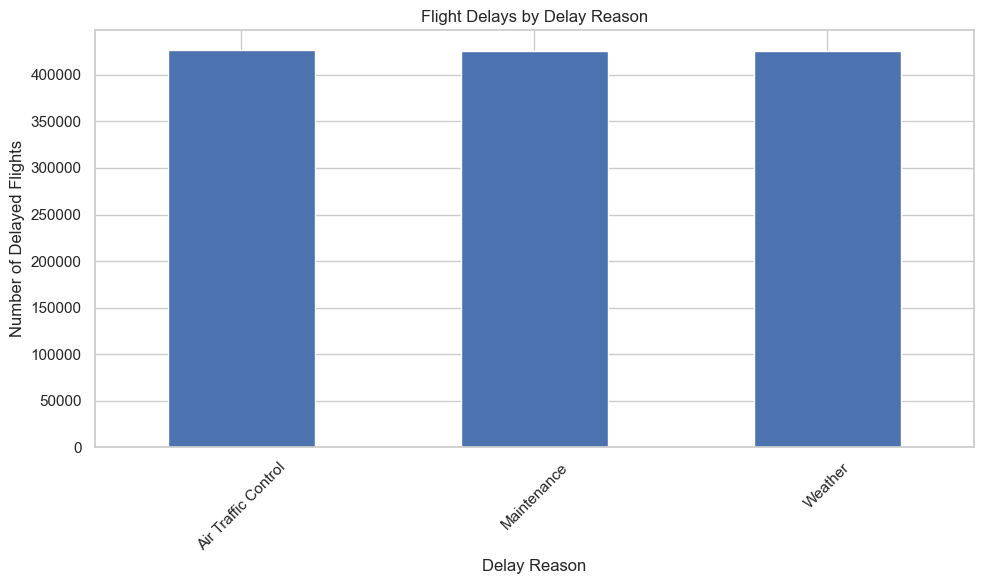

In [47]:
# ============================================================
# CELL 31: DELAY REASON VISUALIZATION
# ============================================================

if "DelayReason" in df.columns:

    plt.figure(figsize=(10, 6))

    reason_delay.plot(
        kind="bar"
    )

    plt.title(
        "Flight Delays by Delay Reason"
    )

    plt.xlabel("Delay Reason")
    plt.ylabel("Number of Delayed Flights")

    plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()

else:

    print("DelayReason column not available.")

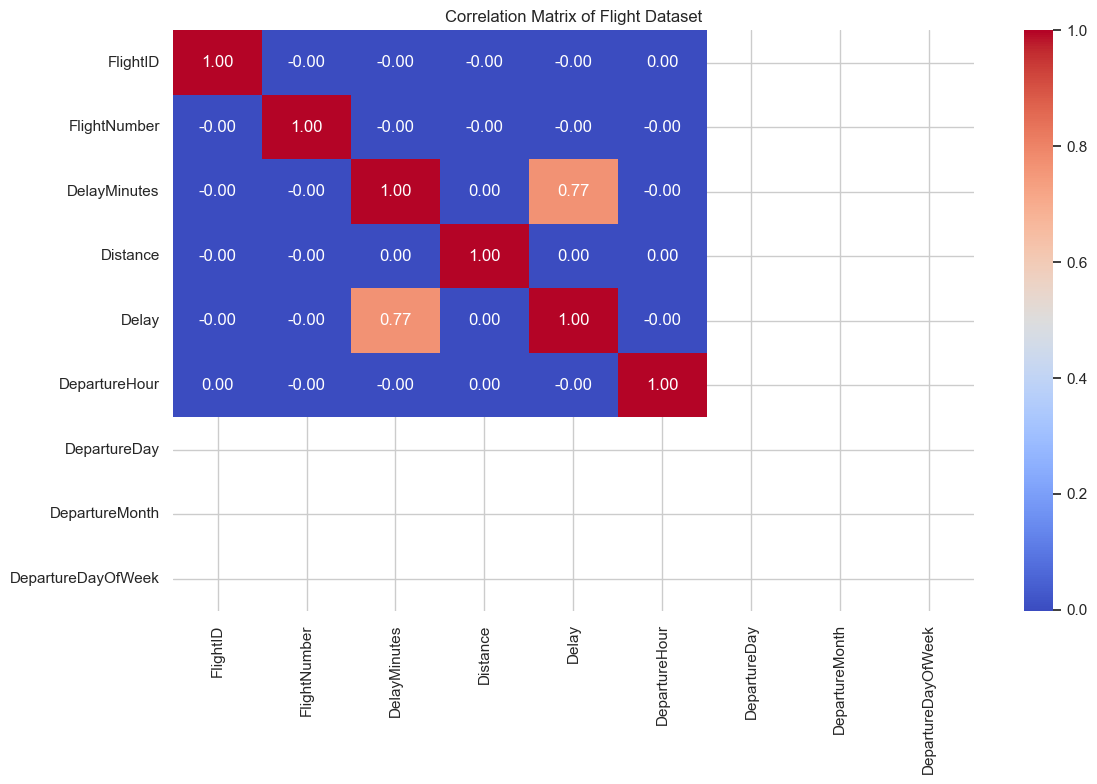

In [50]:
# ============================================================
# CELL 34: CORRELATION HEATMAP
# ============================================================

numeric_data = df.select_dtypes(
    include=np.number
)

plt.figure(figsize=(12, 8))

sns.heatmap(
    numeric_data.corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title(
    "Correlation Matrix of Flight Dataset"
)

plt.tight_layout()
plt.show()

In [51]:
# ============================================================
# CELL 35: PREPARE MACHINE LEARNING FEATURES
# ============================================================

# Create a copy
model_df = df.copy()

# Target
y = model_df["Delay"]

# Remove columns that cause data leakage
columns_to_remove = [
    "Delay",
    "DelayMinutes",
    "DelayReason",
    "ActualDeparture",
    "ActualArrival",
    "Route",
    "FlightID",
    "TailNumber"
]

# Remove only columns that actually exist
columns_to_remove = [
    col for col in columns_to_remove
    if col in model_df.columns
]

X = model_df.drop(
    columns=columns_to_remove
)

print("Columns removed:")
print(columns_to_remove)

print("\nFeatures remaining:")
print(X.columns.tolist())

Columns removed:
['Delay', 'DelayMinutes', 'DelayReason', 'ActualDeparture', 'ActualArrival', 'Route', 'FlightID', 'TailNumber']

Features remaining:
['Airline', 'FlightNumber', 'Origin', 'Destination', 'ScheduledDeparture', 'ScheduledArrival', 'Cancelled', 'Diverted', 'AircraftType', 'Distance', 'DepartureHour', 'DepartureDay', 'DepartureMonth', 'DepartureDayOfWeek']


In [52]:
# ============================================================
# CELL 36: PROCESS SCHEDULED TIME FEATURES
# ============================================================

# Convert scheduled departure to datetime
X["ScheduledDeparture"] = pd.to_datetime(
    X["ScheduledDeparture"],
    errors="coerce"
)

# Convert scheduled arrival to datetime
X["ScheduledArrival"] = pd.to_datetime(
    X["ScheduledArrival"],
    errors="coerce"
)

# Create time features
X["ScheduledDepartureHour"] = (
    X["ScheduledDeparture"].dt.hour
)

X["ScheduledDepartureDay"] = (
    X["ScheduledDeparture"].dt.day
)

X["ScheduledDepartureMonth"] = (
    X["ScheduledDeparture"].dt.month
)

X["ScheduledDepartureWeekday"] = (
    X["ScheduledDeparture"].dt.dayofweek
)

X["ScheduledArrivalHour"] = (
    X["ScheduledArrival"].dt.hour
)

# Remove original datetime columns
X = X.drop(
    columns=[
        "ScheduledDeparture",
        "ScheduledArrival"
    ]
)

print("Time features processed successfully!")

display(X.head())

Time features processed successfully!


,Airline,FlightNumber,Origin,Destination,Cancelled,Diverted,AircraftType,Distance,DepartureHour,DepartureDay,DepartureMonth,DepartureDayOfWeek,ScheduledDepartureHour,ScheduledDepartureDay,ScheduledDepartureMonth,ScheduledDepartureWeekday,ScheduledArrivalHour
0,United,4558,ORD,MIA,True,False,Boeing 737,1031,8,1,9,6,8,1,9,6,12
1,Delta,8021,LAX,MIA,True,True,Airbus A320,1006,10,1,9,6,10,1,9,6,13
2,Southwest,7520,DFW,SFO,True,True,Boeing 737,2980,16,1,9,6,16,1,9,6,17
3,Delta,2046,ORD,BOS,False,False,Boeing 777,1408,14,1,9,6,14,1,9,6,18
4,Delta,6049,LAX,SEA,False,True,Boeing 737,2298,1,1,9,6,1,1,9,6,5


In [53]:
# ============================================================
# CELL 37: ENCODE CATEGORICAL VARIABLES
# ============================================================

categorical_columns = X.select_dtypes(
    include=["object"]
).columns.tolist()

print("Categorical columns:")
print(categorical_columns)

X = pd.get_dummies(
    X,
    columns=categorical_columns,
    drop_first=True
)

print(
    "\nShape after one-hot encoding:",
    X.shape
)

Categorical columns:
['Airline', 'Origin', 'Destination', 'AircraftType']

Shape after one-hot encoding: (1747627, 26)


In [54]:
# ============================================================
# CELL 38: FINAL ML DATA CLEANING
# ============================================================

# Replace infinity values
X = X.replace(
    [np.inf, -np.inf],
    np.nan
)

# Fill missing values
X = X.fillna(0)

# Convert all features to float
X = X.astype(float)

print("Machine Learning data prepared!")
print("Final X shape:", X.shape)
print("Final y shape:", y.shape)

print("\nAny missing values?")
print(X.isnull().sum().sum())

Machine Learning data prepared!
Final X shape: (1747627, 26)
Final y shape: (1747627,)

Any missing values?
0


In [55]:
# ============================================================
# CELL 39: TRAIN TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples :", len(X_test))

Training samples: 1398101
Testing samples : 349526


In [57]:
# ============================================================
# CELL 40: DECISION TREE MODEL
# ============================================================

dt_model = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)

dt_model.fit(
    X_train,
    y_train
)

print("Decision Tree model trained successfully!")

Decision Tree model trained successfully!


In [60]:
# ============================================================
# CELL 41: PREDICTION
# ============================================================

y_pred = dt_model.predict(X_test)

print("Predictions completed!")

print("\nFirst 20 predictions:")
print(y_pred[:20])

Predictions completed!

First 20 predictions:
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]


In [61]:
# ============================================================
# CELL 42: MODEL EVALUATION
# ============================================================

accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred,
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    zero_division=0
)

print("=" * 60)
print("DECISION TREE MODEL PERFORMANCE")
print("=" * 60)

print(
    "Accuracy  :",
    round(accuracy * 100, 2),
    "%"
)

print(
    "Precision :",
    round(precision * 100, 2),
    "%"
)

print(
    "Recall    :",
    round(recall * 100, 2),
    "%"
)

print(
    "F1 Score  :",
    round(f1 * 100, 2),
    "%"
)

DECISION TREE MODEL PERFORMANCE
Accuracy  : 73.15 %
Precision : 73.17 %
Recall    : 99.94 %
F1 Score  : 84.49 %


In [62]:
# ============================================================
# CELL 43: CLASSIFICATION REPORT
# ============================================================

print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "On-Time",
            "Delayed"
        ],
        zero_division=0
    )
)

              precision    recall  f1-score   support

     On-Time       0.29      0.00      0.00     93775
     Delayed       0.73      1.00      0.84    255751

    accuracy                           0.73    349526
   macro avg       0.51      0.50      0.42    349526
weighted avg       0.61      0.73      0.62    349526



In [63]:
# ============================================================
# CELL 44: CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    y_test,
    y_pred
)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[    61  93714]
 [   147 255604]]


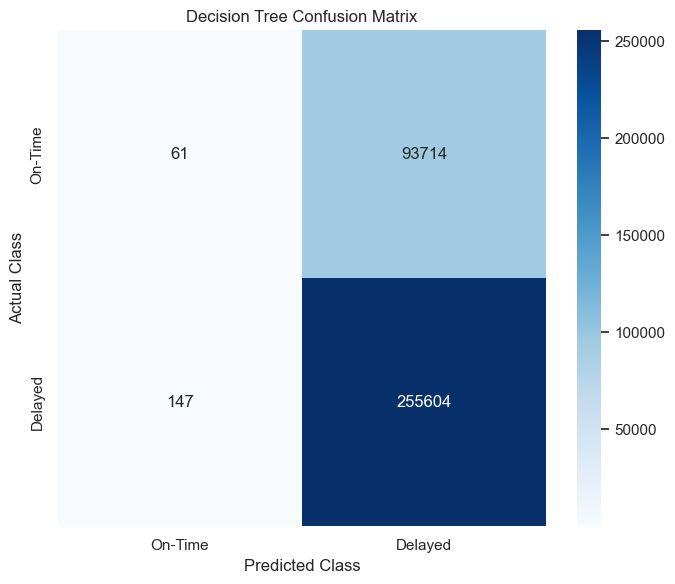

In [64]:
# ============================================================
# CELL 45: CONFUSION MATRIX VISUALIZATION
# ============================================================

plt.figure(figsize=(7, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "On-Time",
        "Delayed"
    ],
    yticklabels=[
        "On-Time",
        "Delayed"
    ]
)

plt.title(
    "Decision Tree Confusion Matrix"
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.tight_layout()
plt.show()

In [65]:
# ============================================================
# CELL 46: FEATURE IMPORTANCE
# ============================================================

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": dt_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print("Top 20 Factors Contributing to Flight Delays:")
display(
    feature_importance.head(20)
)

Top 20 Factors Contributing to Flight Delays:


,Feature,Importance
0,FlightNumber,0.349948
3,Distance,0.221937
12,ScheduledArrivalHour,0.087240
8,ScheduledDepartureHour,0.045669
4,DepartureHour,0.037857
1,Cancelled,0.029738
2,Diverted,0.024452
24,AircraftType_Boeing 737,0.022804
17,Origin_JFK,0.022751
15,Airline_United,0.022127


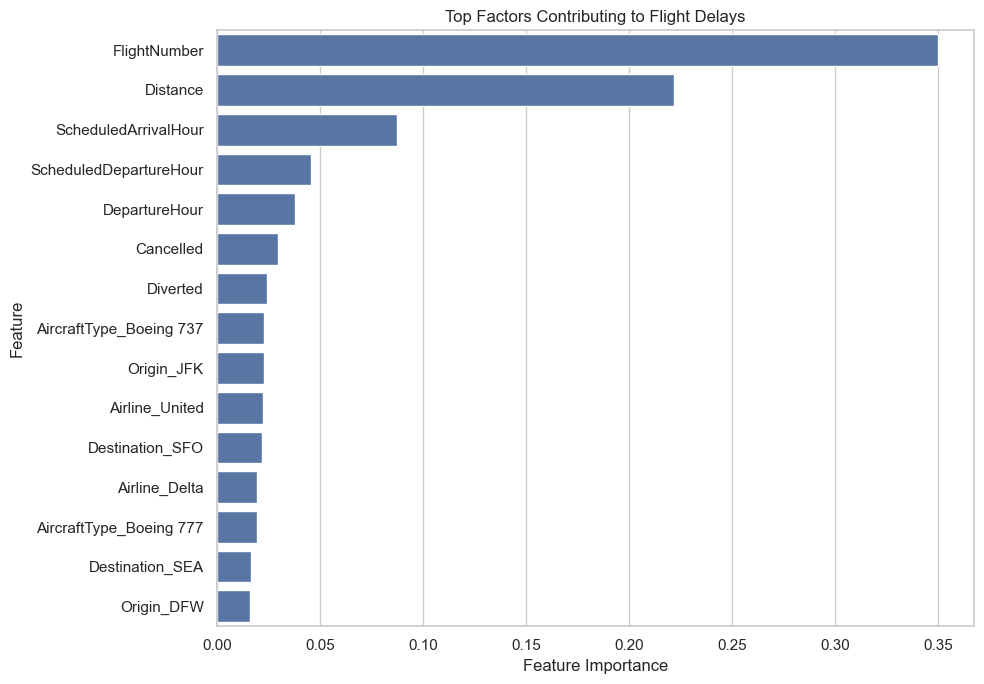

In [66]:
# ============================================================
# CELL 47: FEATURE IMPORTANCE VISUALIZATION
# ============================================================

top_features = feature_importance.head(15)

plt.figure(figsize=(10, 7))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title(
    "Top Factors Contributing to Flight Delays"
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

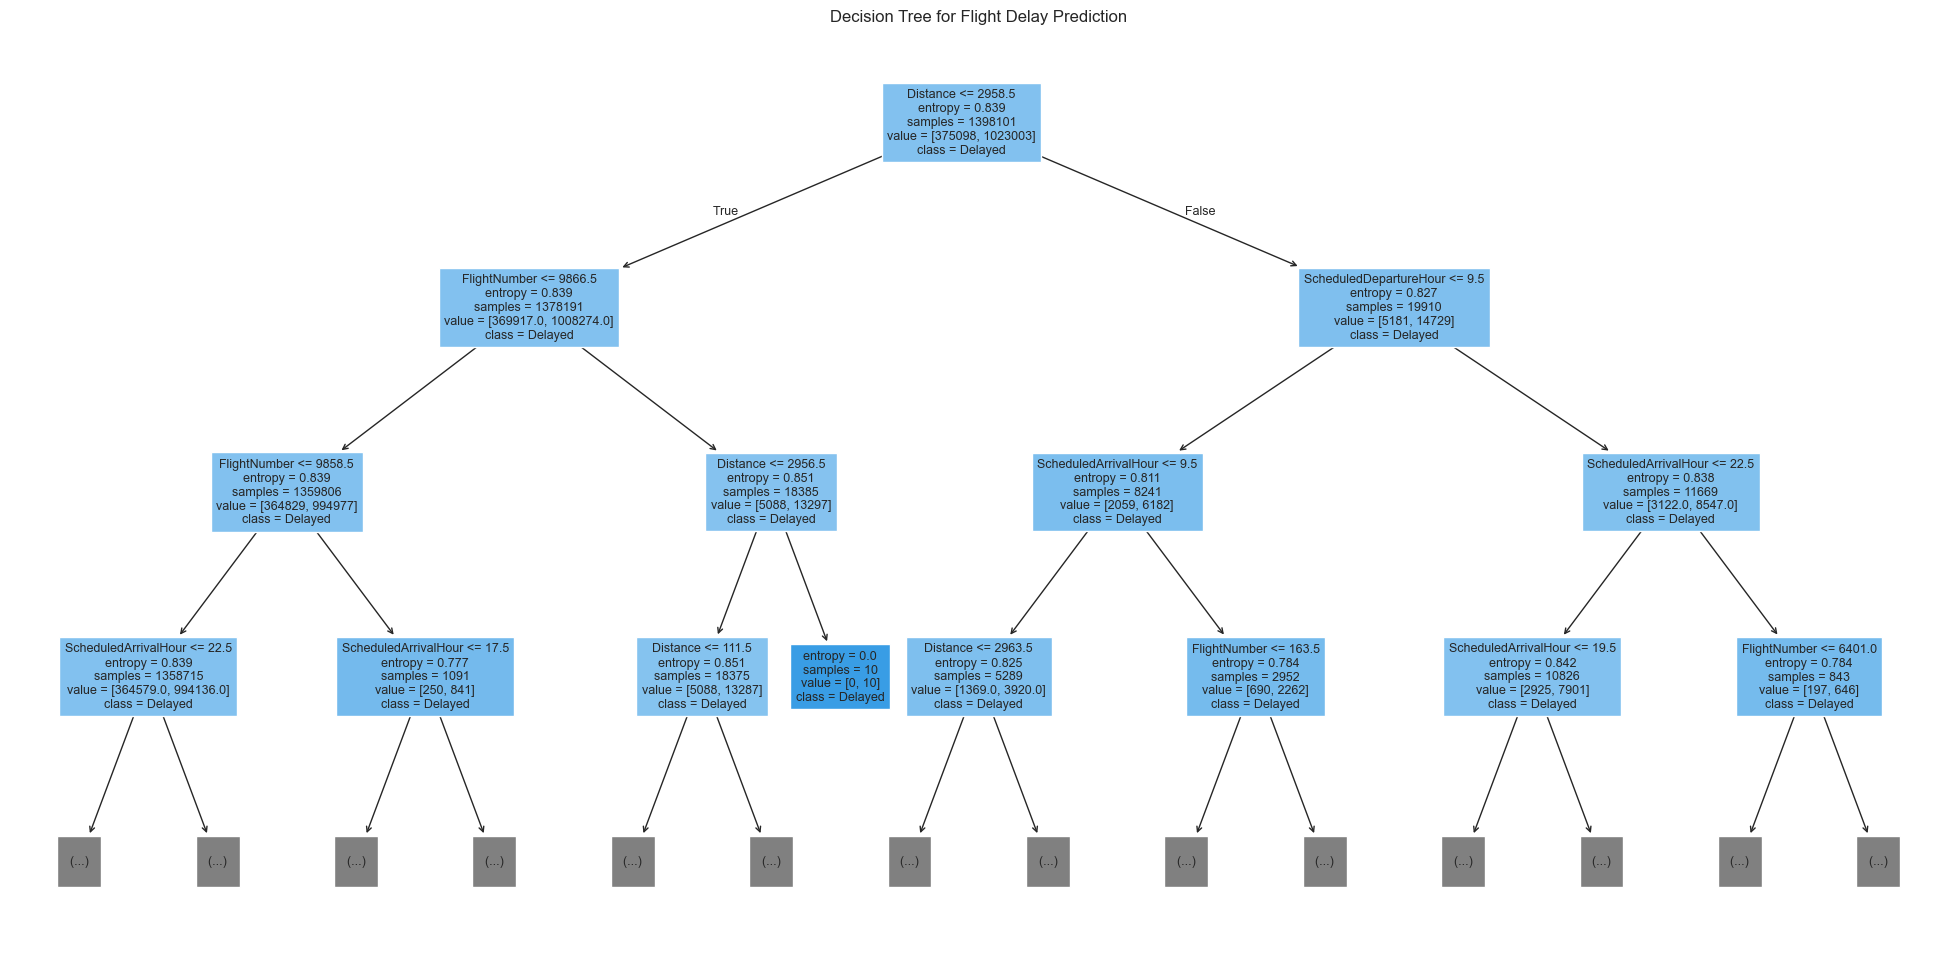

In [67]:
# ============================================================
# CELL 48: DECISION TREE VISUALIZATION
# ============================================================

plt.figure(figsize=(25, 12))

plot_tree(
    dt_model,
    feature_names=X.columns,
    class_names=[
        "On-Time",
        "Delayed"
    ],
    filled=True,
    max_depth=3,
    fontsize=9
)

plt.title(
    "Decision Tree for Flight Delay Prediction"
)

plt.show()

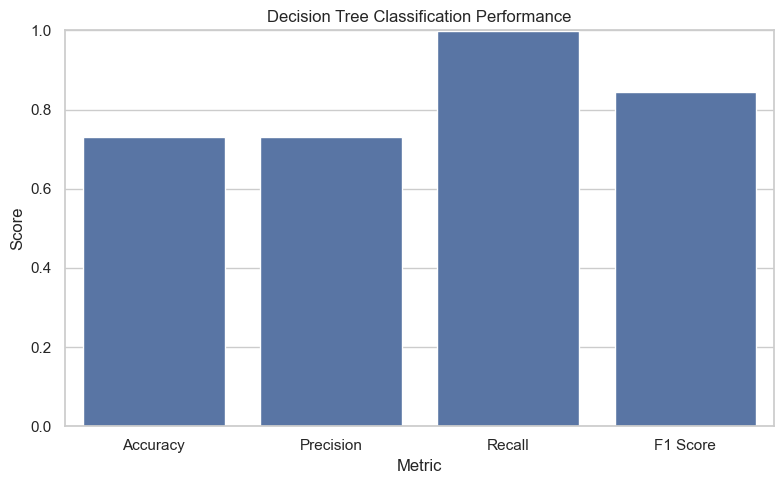

,Metric,Score
0,Accuracy,0.731462
1,Precision,0.731723
2,Recall,0.999425
3,F1 Score,0.844876


In [68]:
# ============================================================
# CELL 49: MODEL PERFORMANCE GRAPH
# ============================================================

metrics = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],
    "Score": [
        accuracy,
        precision,
        recall,
        f1
    ]
})

plt.figure(figsize=(8, 5))

sns.barplot(
    data=metrics,
    x="Metric",
    y="Score"
)

plt.ylim(0, 1)

plt.title(
    "Decision Tree Classification Performance"
)

plt.ylabel("Score")

plt.tight_layout()
plt.show()

display(metrics)

In [69]:
# ============================================================
# CELL 50: FINAL PROJECT SUMMARY
# ============================================================

print("=" * 70)
print("          FLIGHT DELAY PREDICTION - FINAL RESULTS")
print("=" * 70)

print("\nDATASET")
print("-" * 70)

print("Total Flights:", len(df))
print("Total Columns:", df.shape[1])

print("\nDELAY ANALYSIS")
print("-" * 70)

print("On-Time Flights:", on_time_flights)
print("Delayed Flights:", delayed_flights)

print(
    "Overall Delay Rate:",
    round(delayed_percentage, 2),
    "%"
)

print("\nMODEL")
print("-" * 70)

print("Algorithm: Decision Tree Classifier")

print(
    "Accuracy :",
    round(accuracy * 100, 2),
    "%"
)

print(
    "Precision:",
    round(precision * 100, 2),
    "%"
)

print(
    "Recall   :",
    round(recall * 100, 2),
    "%"
)

print(
    "F1 Score :",
    round(f1 * 100, 2),
    "%"
)

print("\nTOP DELAY FACTORS")
print("-" * 70)

for i, row in feature_importance.head(10).iterrows():

    print(
        f"{row['Feature']} : "
        f"{row['Importance']:.4f}"
    )

print("\nWEATHER DATA")
print("-" * 70)

print(
    "Weather variables are not available "
    "in the supplied dataset."
)

print("\nPREVIOUS DELAY DATA")
print("-" * 70)

print(
    "Previous-delay variables are not "
    "available in the supplied dataset."
)

print("\nAnalysis completed successfully!")

          FLIGHT DELAY PREDICTION - FINAL RESULTS

DATASET
----------------------------------------------------------------------
Total Flights: 1747627
Total Columns: 22

DELAY ANALYSIS
----------------------------------------------------------------------
On-Time Flights: 468873
Delayed Flights: 1278754
Overall Delay Rate: 73.17 %

MODEL
----------------------------------------------------------------------
Algorithm: Decision Tree Classifier
Accuracy : 73.15 %
Precision: 73.17 %
Recall   : 99.94 %
F1 Score : 84.49 %

TOP DELAY FACTORS
----------------------------------------------------------------------
FlightNumber : 0.3499
Distance : 0.2219
ScheduledArrivalHour : 0.0872
ScheduledDepartureHour : 0.0457
DepartureHour : 0.0379
Cancelled : 0.0297
Diverted : 0.0245
AircraftType_Boeing 737 : 0.0228
Origin_JFK : 0.0228
Airline_United : 0.0221

WEATHER DATA
----------------------------------------------------------------------
Weather variables are not available in the supplied dataset.


In [73]:
# ============================================================
# CELL 51: SAVE CLEANED DATASET
# ============================================================

cleaned_file = r"C:\Users\navya\Downloads\Cleaned_Flight_Dataset.csv"

df.to_csv(
    cleaned_file,
    index=False
)

print("Cleaned dataset saved successfully!")
print(cleaned_file)

Cleaned dataset saved successfully!
C:\Users\navya\Downloads\Cleaned_Flight_Dataset.csv


In [74]:
# ============================================================
# CELL 52: SAVE MODEL RESULTS
# ============================================================

results_file = r"C:\Users\navya\Downloads\Flight_Delay_Model_Results.csv"

metrics.to_csv(
    results_file,
    index=False
)

print("Model results saved successfully!")
print(results_file)

Model results saved successfully!
C:\Users\navya\Downloads\Flight_Delay_Model_Results.csv
